In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture



In [ ]:
df = pd.read_csv('CC GENERAL.csv')

In [ ]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

###Droping Customer ID, Negligible Info

In [ ]:
df.drop(columns=['CUST_ID'],inplace=True)

In [ ]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.duplicated().sum()

np.int64(0)

###Checking NaN Values

In [ ]:
df.isna().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


##Let's check why do we have 313 Nans on minimum payments.

In [ ]:
df[df['MINIMUM_PAYMENTS'].isna()]


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8919,14.524779,0.333333,152.00,152.00,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,1500.0,0.000000,NaN,0.0,6
8929,371.527312,0.333333,0.00,0.00,0.0,1465.407927,0.000000,0.000000,0.000000,0.166667,5,0,1500.0,0.000000,NaN,0.0,6
8935,183.817004,1.000000,465.90,0.00,465.9,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,0.000000,NaN,0.0,6
8944,193.571722,0.833333,1012.73,1012.73,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,4000.0,0.000000,NaN,0.0,6


### For most records where `MINIMUM_PAYMENTS` is NaN, the `PAYMENTS` value is 0. This suggests that these credit card users are not making any payments — either they are accumulating debt or they are inactive users with zero balance.

In [ ]:
df[(df['MINIMUM_PAYMENTS'].isna()) & (df['PAYMENTS'] == 0)].count()[0]


/tmp/ipython-input-3981571256.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df[(df['MINIMUM_PAYMENTS'].isna()) & (df['PAYMENTS'] == 0)].count()[0]


np.int64(240)

###We can put the `MINIMUM_PAYMENTS` for those with zero balance = 0, and fill the rest with median value..

In [ ]:
df[(df['MINIMUM_PAYMENTS'].isna()) & (df['PAYMENTS'] == 0)] = 0

In [ ]:
df.isna().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [ ]:
df[df['MINIMUM_PAYMENTS'].isna()]
#seeing the rest of 73 nan vals for minimum payment

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
54,6.660517,0.636364,310.00,0.00,310.00,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
99,0.000000,0.000000,0.00,0.00,0.00,89.849004,0.000000,0.000000,0.000000,0.142857,1,0,3000.0,138.021428,NaN,0.0,7
146,19.354559,0.909091,689.70,0.00,689.70,0.000000,0.833333,0.000000,0.833333,0.000000,0,10,10000.0,746.691026,NaN,0.0,12
319,0.478714,0.090909,734.97,159.00,575.97,0.000000,0.833333,0.083333,0.750000,0.000000,0,16,6000.0,1159.135064,NaN,0.0,12
1155,34.207779,0.090909,2483.26,2483.26,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,10000.0,29272.486070,NaN,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8561,3.229304,0.545455,190.20,0.00,190.20,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1500.0,295.937124,NaN,0.0,12
8593,16.887571,0.363636,1083.00,1083.00,0.00,0.000000,0.250000,0.250000,0.000000,0.000000,0,3,1200.0,3905.430817,NaN,0.0,12
8647,0.006651,0.142857,0.00,0.00,0.00,164.137866,0.000000,0.000000,0.000000,0.142857,1,0,1200.0,5.070726,NaN,0.0,7
8753,0.223351,0.090909,336.00,0.00,336.00,0.000000,1.000000,0.000000,0.916667,0.000000,0,12,1000.0,578.819329,NaN,0.0,12


(array([7.814e+03, 7.040e+02, 1.640e+02, 5.800e+01, 3.200e+01, 1.800e+01,
        1.500e+01, 1.300e+01, 1.600e+01, 3.000e+00, 7.000e+00, 4.000e+00,
        5.000e+00, 4.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 4.000e+00,
        3.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([    0.       ,  1528.1241504,  3056.2483008,  4584.3724512,
         6112.4966016,  7640.620752 ,  9168.7449024, 10696.8690528,
        12224.9932032, 13753.1173536, 15281.241504 , 16809.3656544,
        18337.4898048, 19865.6139552, 21393.7381056, 22921.862256 ,
        24449.9864064, 25978.1105568, 27506.2347072, 29034.3588576,
        30562.483008 , 32090.6071584

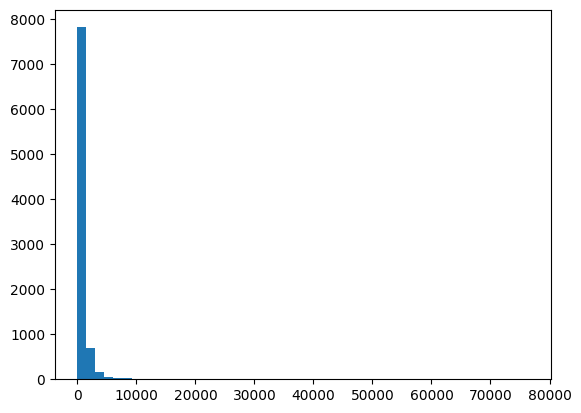

In [ ]:
plt.hist(df['MINIMUM_PAYMENTS'],bins = 50)


###Minimum payments is right skewed, most values are low.

In [ ]:
df['MINIMUM_PAYMENTS'].median()

294.572557

#We'll drop the column where `CREDIT_LIMIT` is NaN, it's one record anyways. Probably data entry problem

In [ ]:
df.loc[df['CREDIT_LIMIT'].isna()]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


In [ ]:
df.drop(5203, inplace=True)

In [ ]:
#Filling rest with median

df['MINIMUM_PAYMENTS']= df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

#Handled all NaNs Successfully.

In [ ]:
df.isna().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


#Let's now Explore the Data.

The `BALANCE` feature is right-skewed: most customers carry relatively low debt, while a smaller number have high balances. Some of these high-balance customers may simply be wealthier and capable of managing larger debts.

(array([6.576e+03, 1.316e+03, 5.680e+02, 2.750e+02, 1.340e+02, 4.000e+01,
        2.100e+01, 1.100e+01, 6.000e+00, 2.000e+00]),
 array([    0.      ,  1904.313856,  3808.627712,  5712.941568,
         7617.255424,  9521.56928 , 11425.883136, 13330.196992,
        15234.510848, 17138.824704, 19043.13856 ]),
 <BarContainer object of 10 artists>)

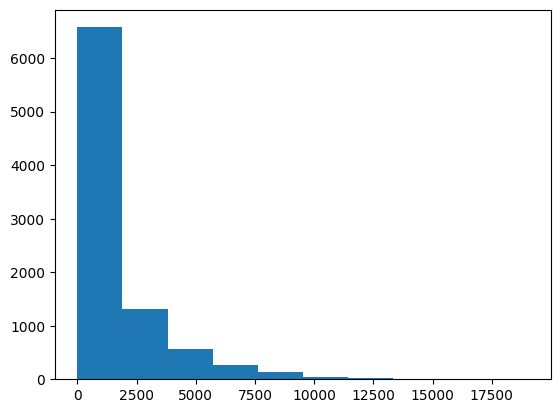

In [ ]:
plt.hist(df['BALANCE'],bins = 10)

#Same thing with `CREDIT_LIMIT`, this is representative of incomes of people. some people are rich with high credit limit, others are not. some people are of medium standard of living.

(array([3.932e+03, 2.331e+03, 1.575e+03, 6.610e+02, 2.680e+02, 1.160e+02,
        5.400e+01, 8.000e+00, 1.000e+00, 3.000e+00]),
 array([    0.,  3000.,  6000.,  9000., 12000., 15000., 18000., 21000.,
        24000., 27000., 30000.]),
 <BarContainer object of 10 artists>)

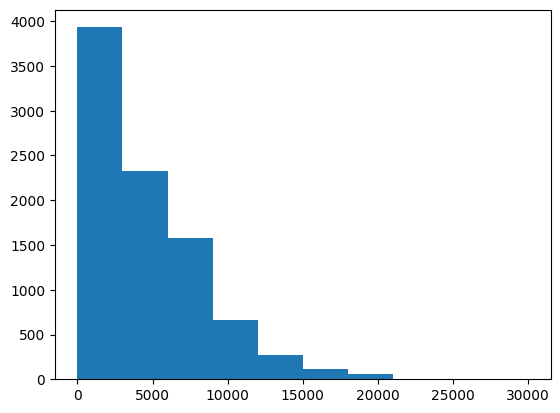

In [ ]:
plt.hist(df['CREDIT_LIMIT'], bins=10)

#How long have been the users holding their credit card?

<Axes: xlabel='TENURE', ylabel='count'>

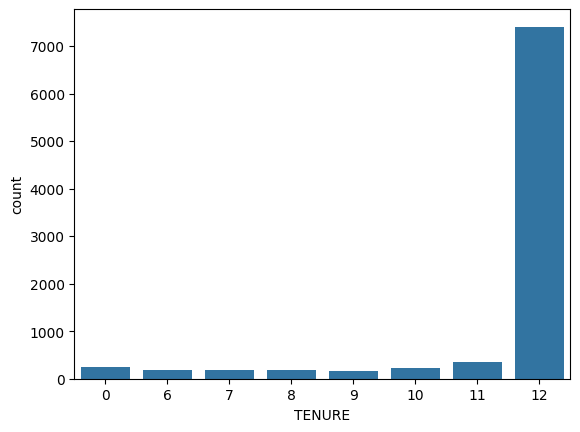

In [ ]:
sns.countplot(data=df,x='TENURE')

#We can see that some credit card holders are brand new with 0 month tenure, this data was collected for last 6month behavior.. let's see these 0month tenure users! Probably not enough data collected for their behavior

In [ ]:
df[df['TENURE']==0]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
8919,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
8929,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
8935,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0


#All users with tenure 0 are FULL Zero Rows. I'll just drop these 240 rows. They give 0 insight about user behavior. just dummy data.

In [ ]:
df = df[df['TENURE'] != 0]


#This made me check if there are other full zero rows. But there are none.

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
full_zero_rows = df[(df[numeric_cols] == 0).all(axis=1)]
print(f"Number of full-zero rows: {full_zero_rows.shape[0]}")
full_zero_rows


Number of full-zero rows: 0


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


#Purchases are right skewed.
#Most customemrs have low or medium spending.

(array([8.406e+03, 2.320e+02, 4.500e+01, 4.000e+00, 8.000e+00, 7.000e+00,
        2.000e+00, 2.000e+00, 2.000e+00, 1.000e+00]),
 array([    0.   ,  4903.957,  9807.914, 14711.871, 19615.828, 24519.785,
        29423.742, 34327.699, 39231.656, 44135.613, 49039.57 ]),
 <BarContainer object of 10 artists>)

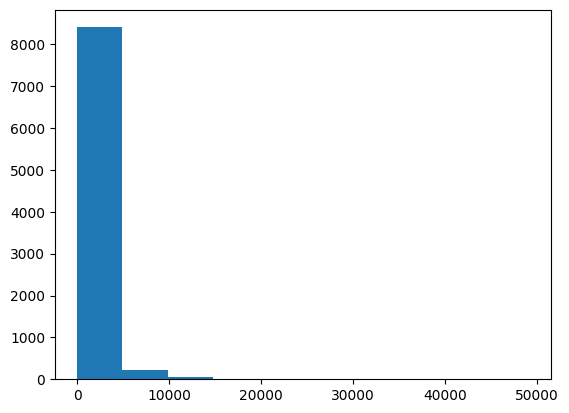

In [ ]:
plt.hist(df['PURCHASES'],bins=10)


#Right skewed. same.


(array([8.273e+03, 3.400e+02, 6.700e+01, 1.600e+01, 8.000e+00, 3.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([    0.      ,  4713.721176,  9427.442352, 14141.163528,
        18854.884704, 23568.60588 , 28282.327056, 32996.048232,
        37709.769408, 42423.490584, 47137.21176 ]),
 <BarContainer object of 10 artists>)

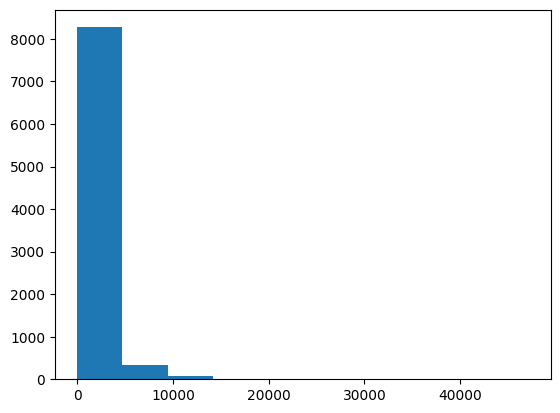

In [ ]:
plt.hist(df['CASH_ADVANCE'],bins=10)

#We have like 2 distributions here. we have a significant amount of people with low frequency, and also significant amount of people with high frequency, its multimodal

(array([2648.,  475.,  399.,  373.,  327.,  756.,  345.,  330.,  466.,
        2590.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

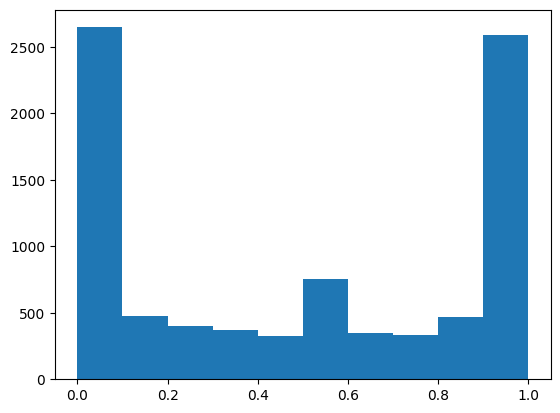

In [ ]:
plt.hist(df['PURCHASES_FREQUENCY'])

array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

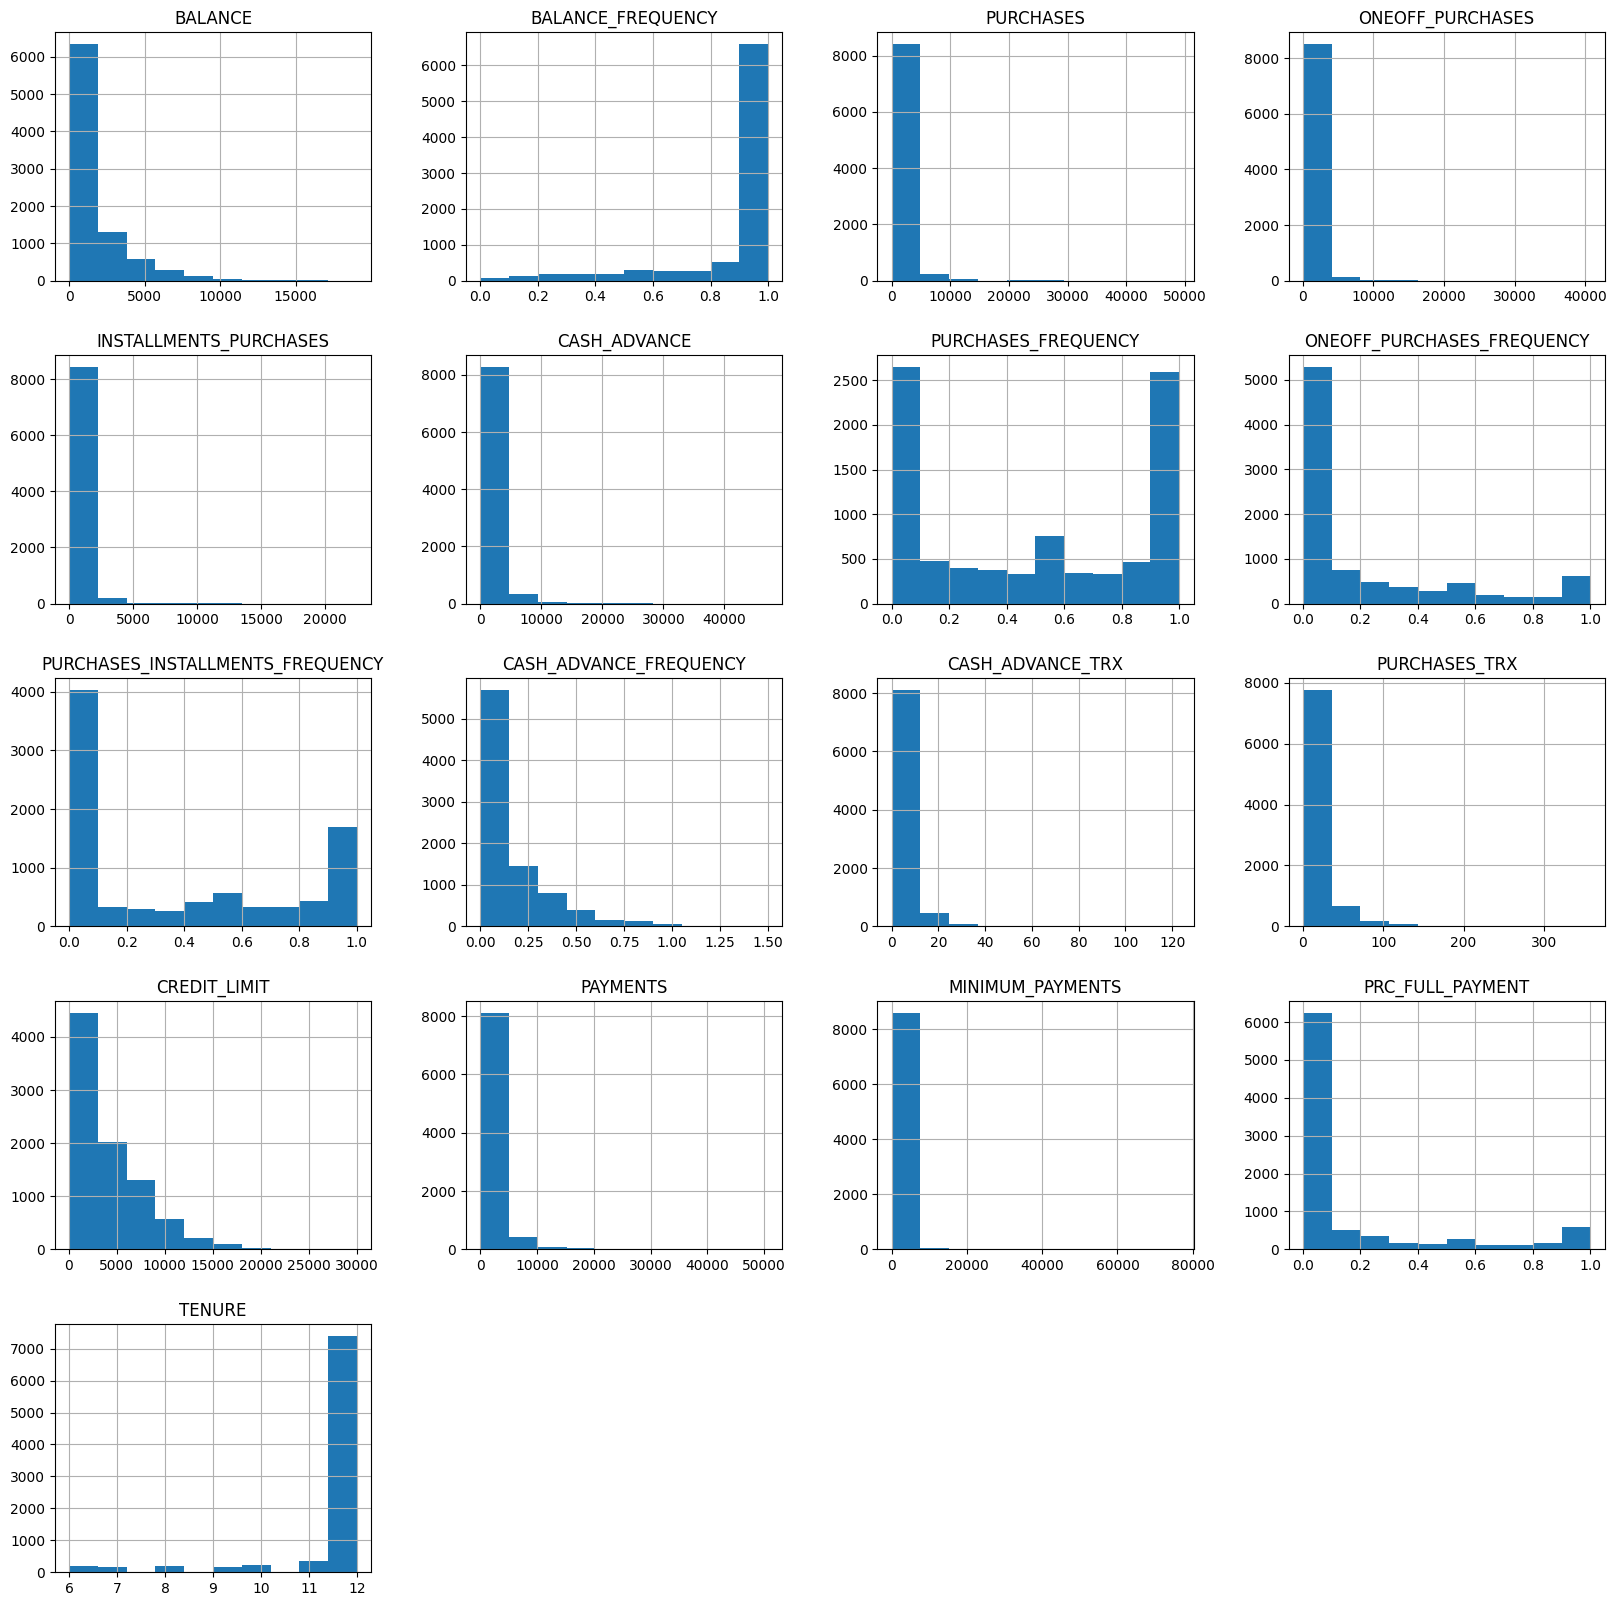

In [ ]:
df.hist(figsize=(20,20))


- PURCHASES_FREQUENCY is strongly correlated with PURCHASES_INSTALLMENTS_FREQUENCY (0.86), indicating consistent purchasing behavior patterns.

- CASH_ADVANCE_FREQUENCY and CASH_ADVANCE_TRX are highly correlated (0.80), meaning transaction count largely reflects frequency.

- Cash advance variables show weak or negative correlation with purchase variables → suggests different customer behavior segments.

- CREDIT_LIMIT moderately correlates with BALANCE (0.54) and PAYMENTS (0.43), indicating higher-limit customers tend to spend and pay more.

- MINIMUM_PAYMENTS has weak correlations overall → may represent a distinct financial behavior group (e.g., revolving customers).

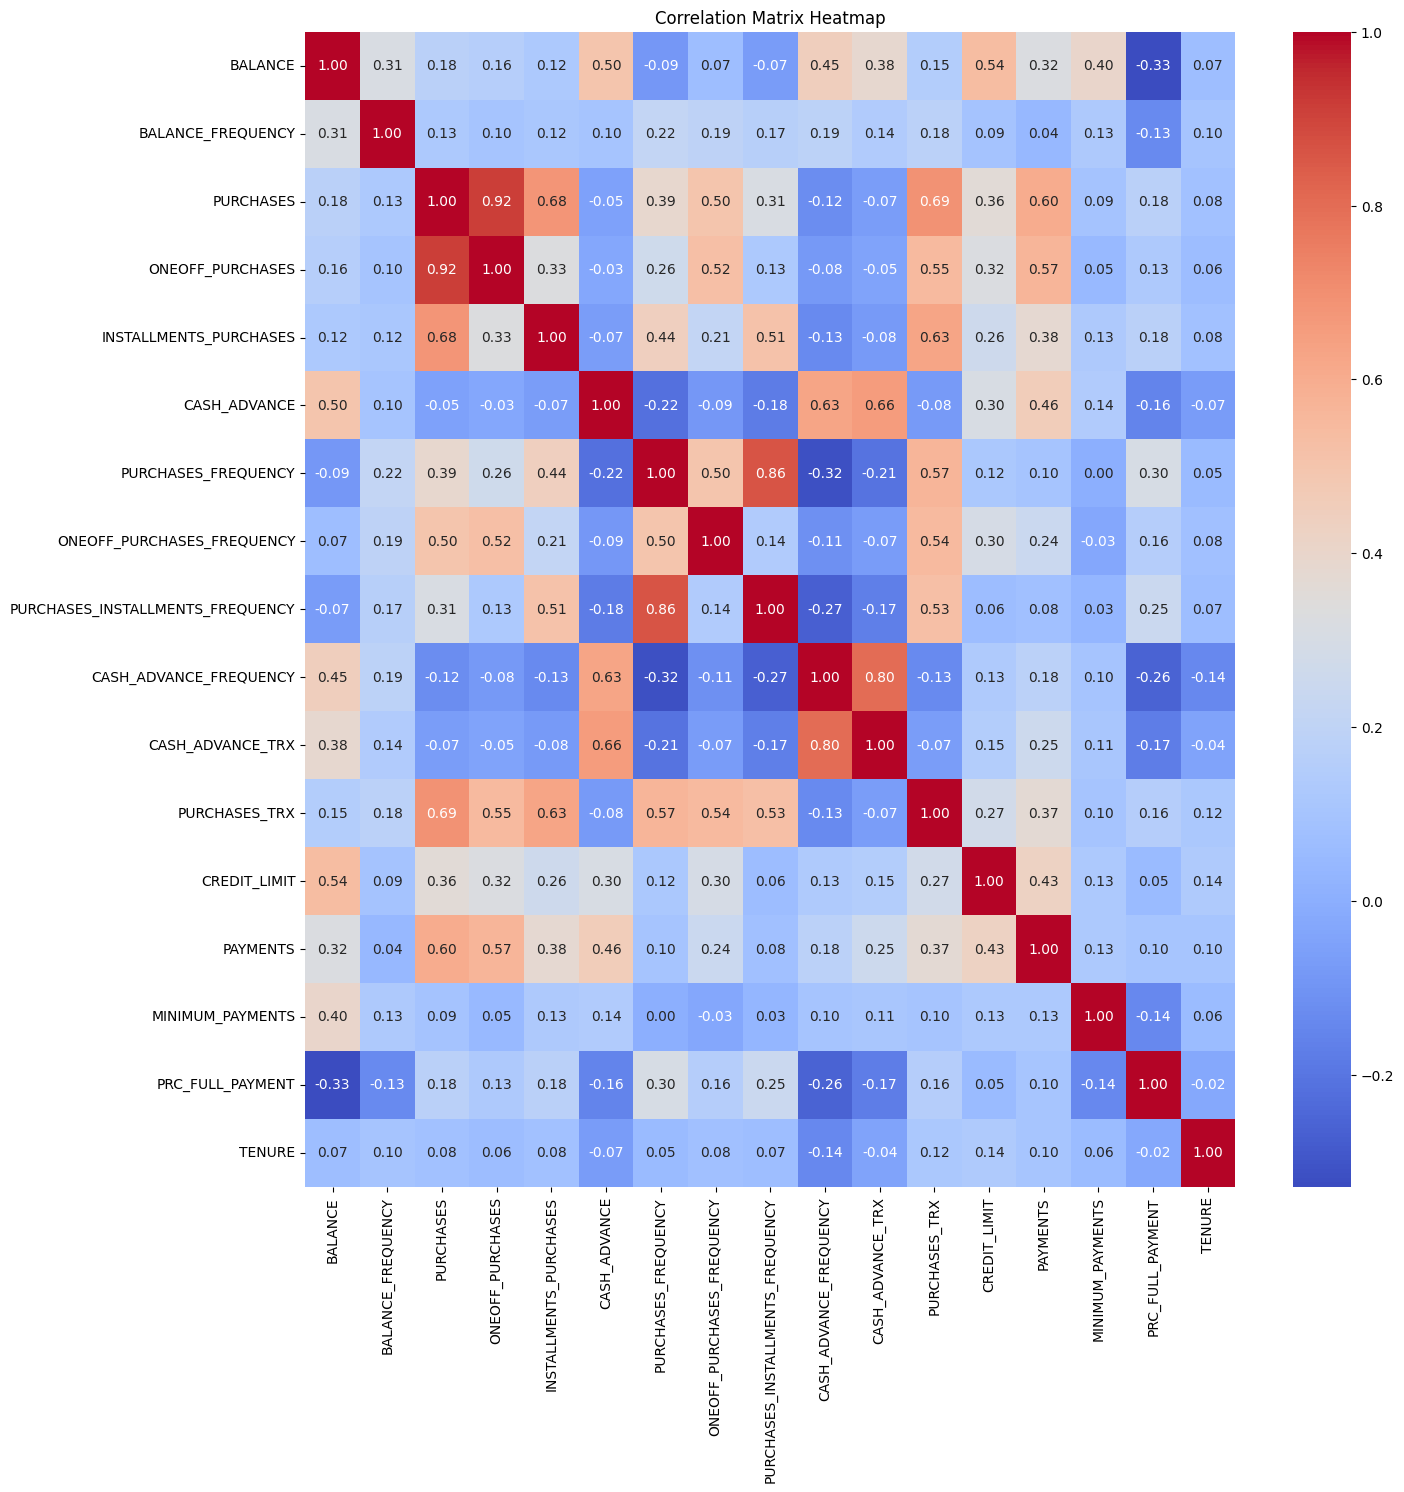

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(15, 15)) # Adjust figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

#more corr with balance (debts) is with cash advance, because when u take cash. more interest. more debts.
#same with balance vs credit limit. more money more debt. trivial
#Rest of high correlations are obvious why. more purchases more purchase transactions etc


#Let's log transform the unbounded right skewed distributions [payments,credit_limit,minimum_payments,cash_advance,installments_purchases,purchases,oneoff_purchases,balance]

In [ ]:



right_skewed = [
    'PAYMENTS', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS', 'CASH_ADVANCE',
    'INSTALLMENTS_PURCHASES', 'PURCHASES', 'ONEOFF_PURCHASES', 'BALANCE','PURCHASES_TRX','CASH_ADVANCE_TRX',
]

bounded_features = [
    'BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT','TENURE'
]

# Transformers
log_scaler = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=True)),
    ('scale', StandardScaler())
])

scale_only = Pipeline([
    ('scale', StandardScaler())
])

# ColumnTransformer to handle different transformations
preprocessor = ColumnTransformer([
    ('log_scaled', log_scaler, right_skewed),
    ('scaled', scale_only, bounded_features)
])

X_scaled_array = preprocessor.fit_transform(df[right_skewed + bounded_features])

feature_names = right_skewed + bounded_features

X_scaled = pd.DataFrame(X_scaled_array, columns=feature_names, index=df.index)


array([[<Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>,
        <Axes: title={'center': 'BALANCE'}>],
       [<Axes: title={'center': 'PURCHASES_TRX'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

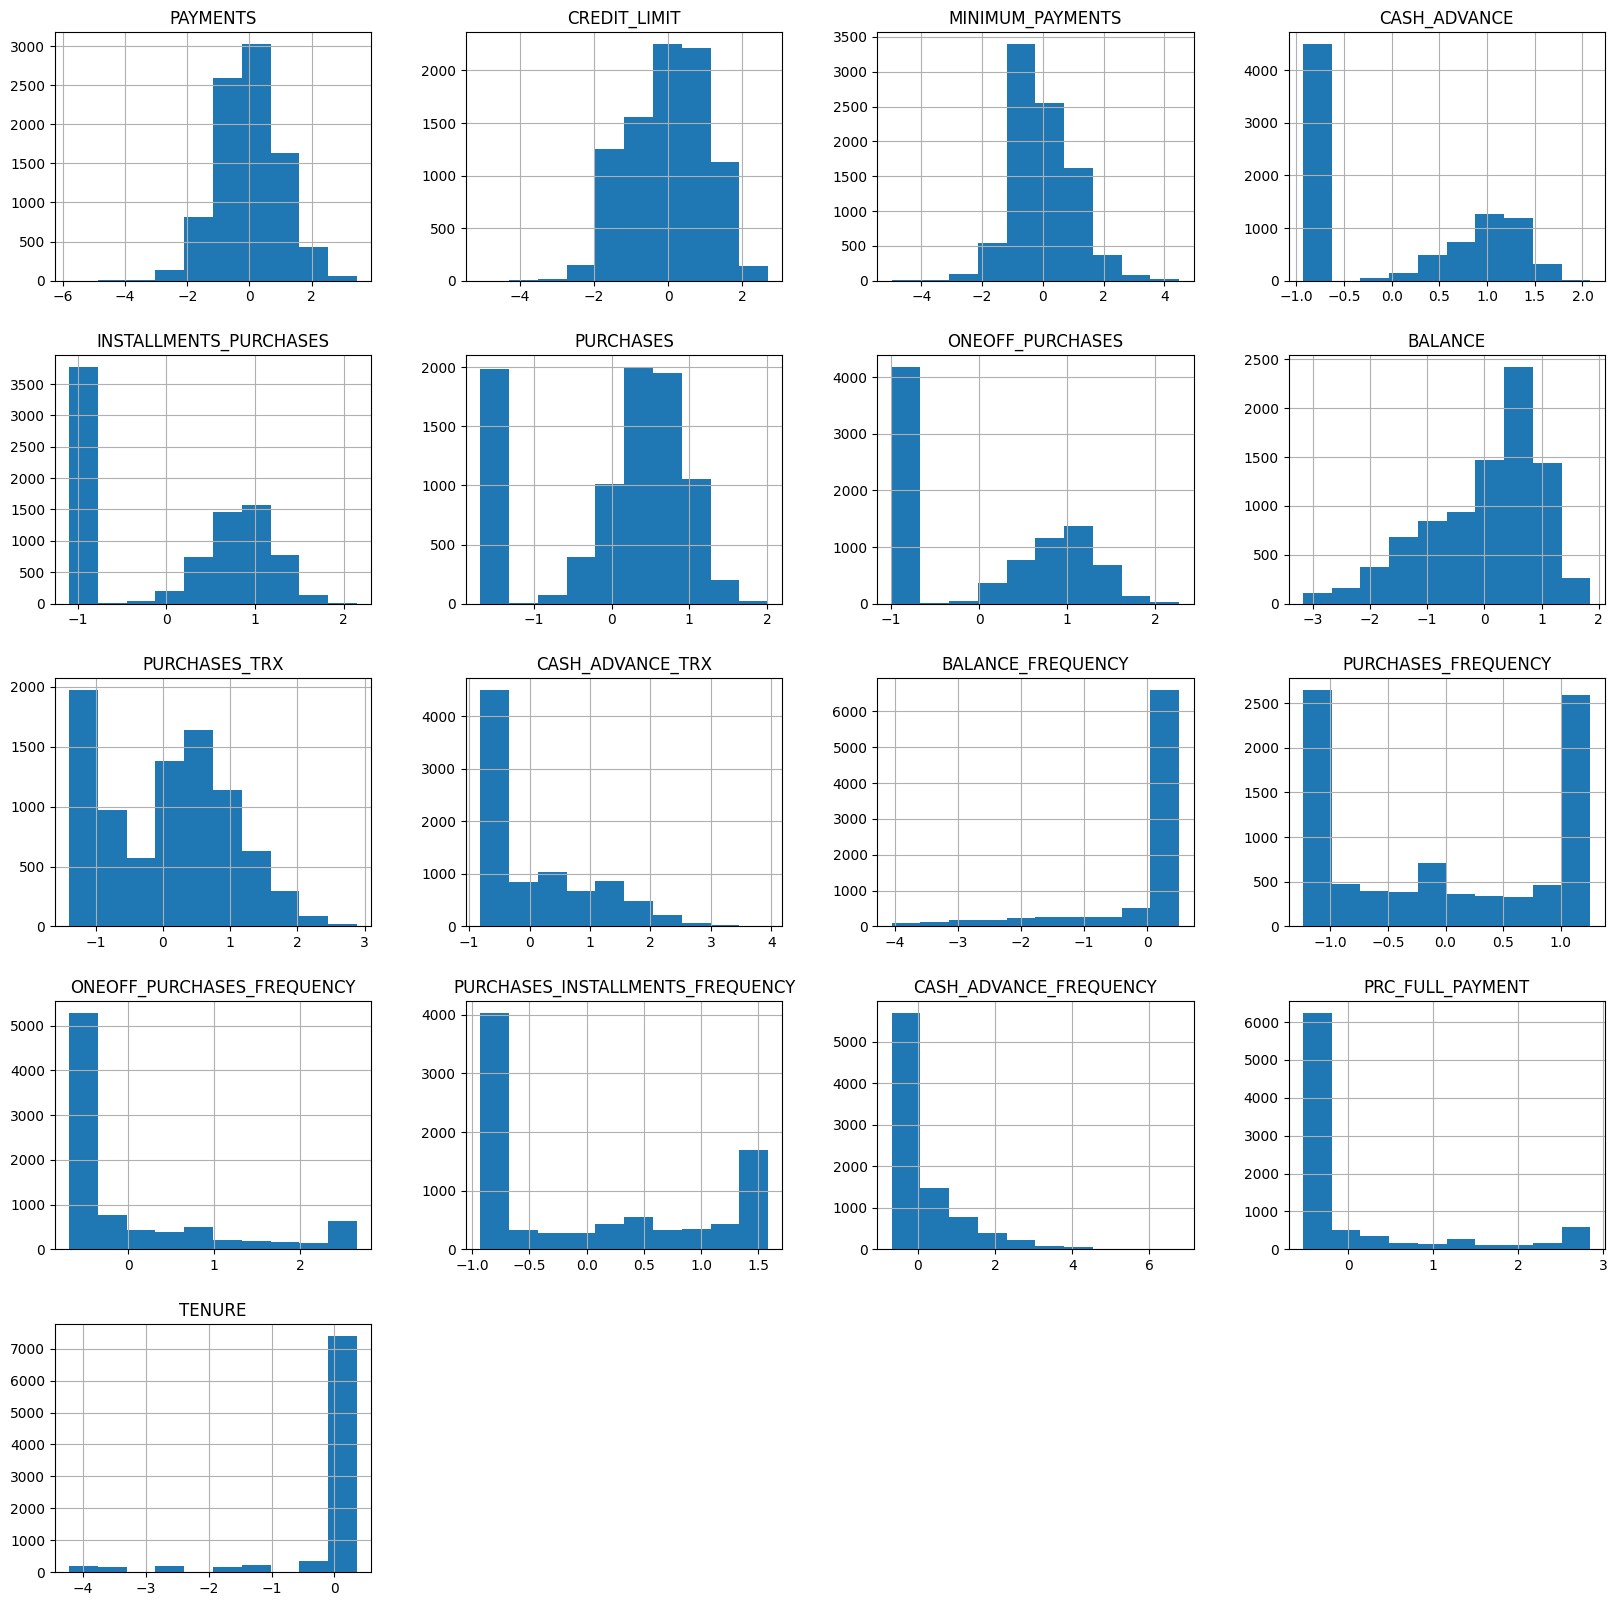

In [ ]:
X_scaled.hist(figsize=(20,20))

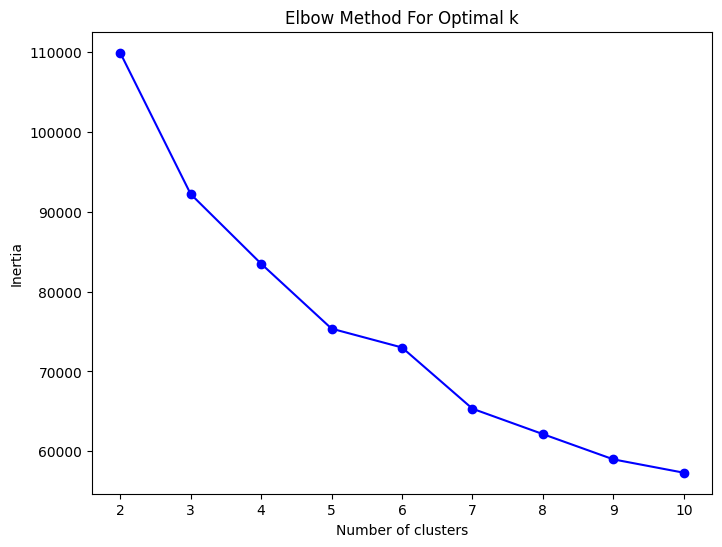

In [ ]:
K = range(2, 11)
inertia = []
models  = []

for k in K:
    kmeans = KMeans(n_clusters=k)
    models.append(kmeans)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow
plt.figure(figsize=(8,6))
plt.plot(K, inertia, 'o-', color='blue')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

Let's try silhuoette score.

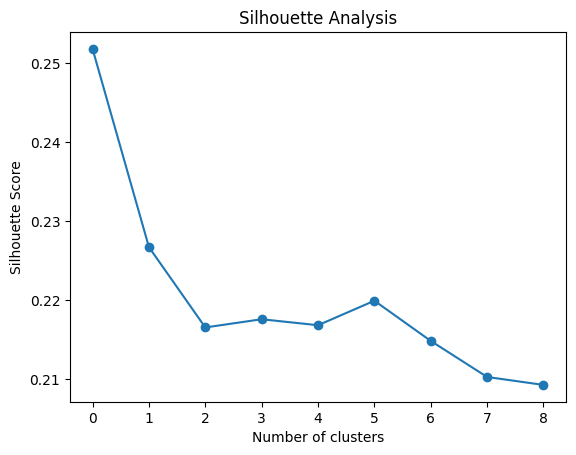

In [ ]:



sil_scores = []
K = range(len(models))
for i in K:
    kmeans = models[i]
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K, sil_scores, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()


### Take K = 7

In [ ]:

# KMeans for 7 clusters
kmeans = models[5]
df['cluster'] = kmeans.fit_predict(X_scaled)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


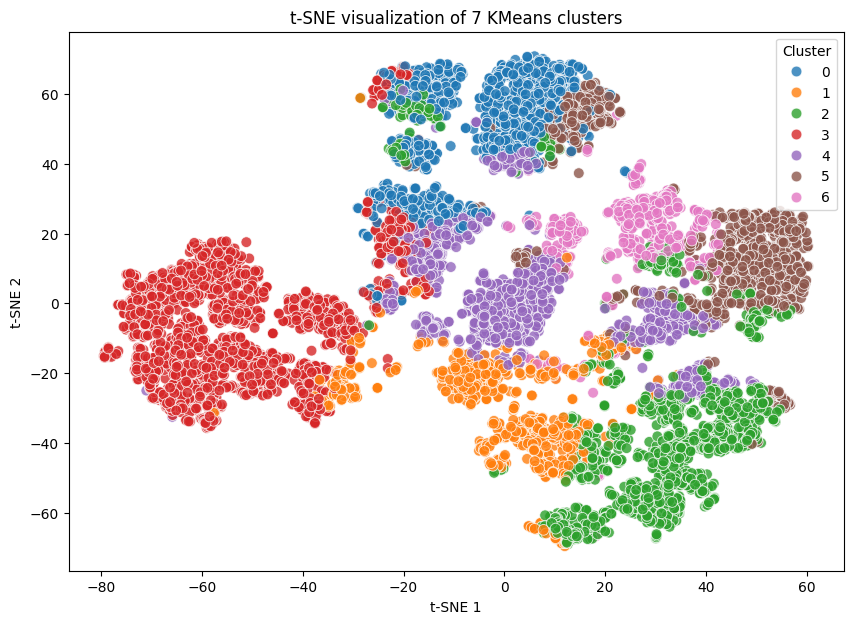

In [ ]:

# t-SNE on scaled features
tsne = TSNE(n_components=2, perplexity=50, n_iter=1000)
X_embedded = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=X_embedded[:,0], y=X_embedded[:,1],
    hue=df['cluster'],
    palette='tab10',
    s=60,
    alpha=0.8
)
plt.title('t-SNE visualization of 7 KMeans clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster')
plt.show()


#Let's try DBScan

In [ ]:

dbscan = DBSCAN(eps=1.3, min_samples=10)  # adjust eps/min_samples
dbscan_labels = dbscan.fit_predict(X_scaled)

df['dbscan_cluster'] = dbscan_labels

#DBScan is Obviously bad.

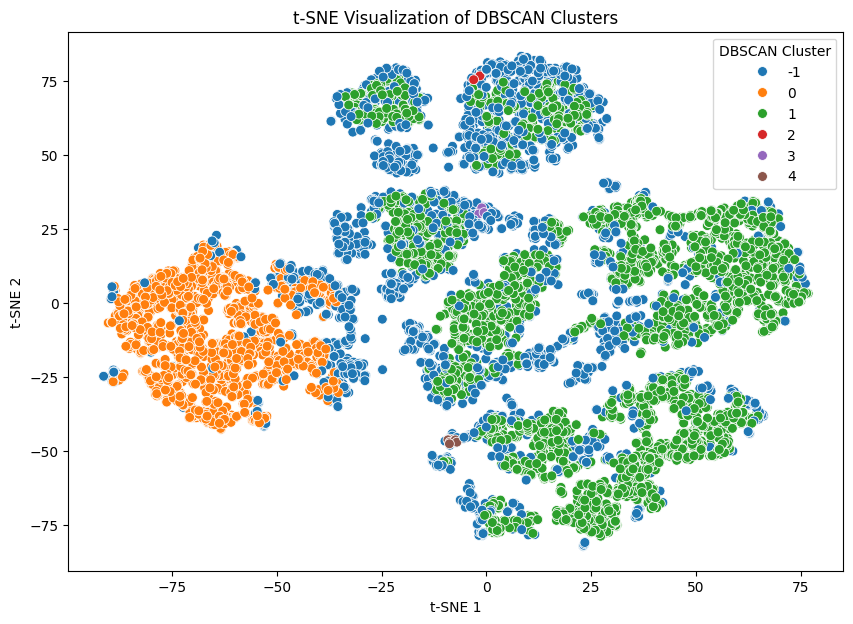

In [ ]:
tsne = TSNE(n_components=2, perplexity=30)
tsne_results = tsne.fit_transform(X_scaled)

df['tsne_1'] = tsne_results[:,0]
df['tsne_2'] = tsne_results[:,1]
plt.figure(figsize=(10,7))
palette = sns.color_palette("tab10", np.unique(dbscan_labels).size)
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='dbscan_cluster',
    palette=palette,
    data=df,
    legend='full',
    s=50
)
plt.title("t-SNE Visualization of DBSCAN Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="DBSCAN Cluster")
plt.show()

#Lets try GMM

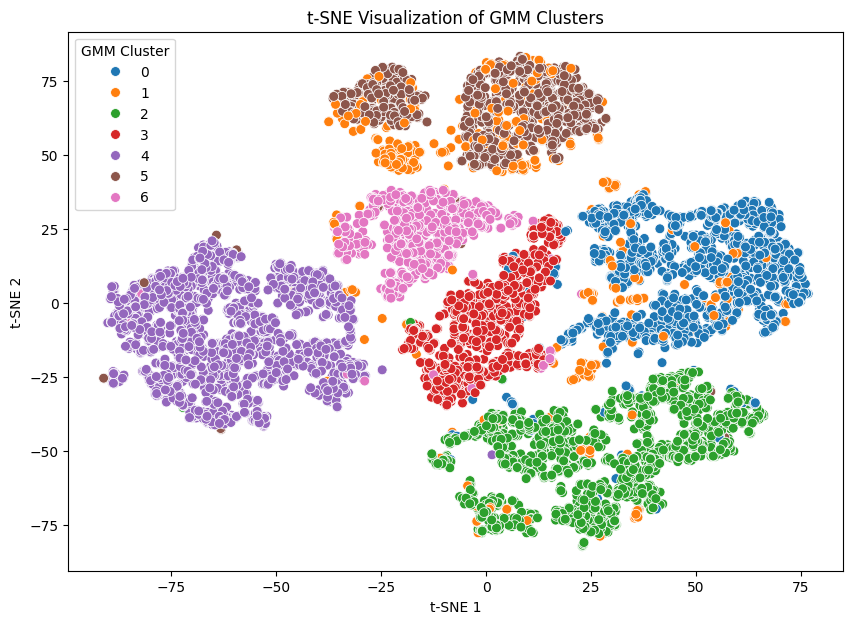

In [ ]:
n_clusters = 7

gmm = GaussianMixture(n_components=n_clusters, covariance_type='full',n_init=100)
gmm.fit(X_scaled)

# Assign cluster based on highest probability
gmm_labels = gmm.predict(X_scaled)
df['gmm_cluster'] = gmm_labels

tsne = TSNE(n_components=2, perplexity=30)
tsne_results = tsne.fit_transform(X_scaled)

df['tsne_1'] = tsne_results[:,0]
df['tsne_2'] = tsne_results[:,1]

plt.figure(figsize=(10,7))
palette = sns.color_palette("tab10", n_clusters)
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='gmm_cluster',
    palette=palette,
    data=df,
    legend='full',
    s=50
)
plt.title("t-SNE Visualization of GMM Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="GMM Cluster")
plt.show()

#GMM Looks slightly better than Kmeans on the t-SNE plot, let's check summary table and see if it makes business sense.

In [ ]:
all_features = [
    'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'
]

cluster_summary_gmm = df.groupby('gmm_cluster')[all_features].agg(['mean', 'median']).round(2)
cluster_summary_gmm

BALANCE         BALANCE_FREQUENCY        PURCHASES         ONEOFF_PURCHASES        INSTALLMENTS_PURCHASES        CASH_ADVANCE         PURCHASES_FREQUENCY         \
               mean  median              mean median      mean  median             mean median                   mean median         mean  median                mean median   
gmm_cluster                                                                                                                                                                    
0           1255.90  549.92              0.94   1.00   2528.42 1573.35          1546.89 787.48                 981.94 561.48         0.00    0.00                0.82   0.92   
1           1280.51  734.78              0.87   0.91   1472.69  784.63           837.73 255.62                 637.87 378.35      1613.75  718.24                0.73   0.83   
2            406.73   59.61              0.81   1.00    546.63  332.80             0.00   0.00                 546.63 332.80         0.00    0.00                0.72   0.83   
3            777.39  264.57              0.78   1.00    900.86  453.00           900.86 453.00                   0.00   0.00         0.00    0.00                0.36   0.25   
4           2199.75 1500.66              0.90   1.00      0.00    0.00             0.00   0.00                   0.00   0.00      2003.28 1206.72                0.00   0.00   
5           3207.00 2379.02              1.00   1.00   1524.23  908.66           797.58 255.16                 727.13 422.06      2049.46 1139.57                0.74   0.83   
6           2365.04 1608.16              0.93   1.00    664.21  285.69           664.21 285.69                   0.00   0.00      2046.09 1159.17                0.28   0.17   

            ONEOFF_PURCHASES_FREQUENCY        PURCHASES_INSTALLMENTS_FREQUENCY        CASH_ADVANCE_FREQUENCY        CASH_ADVANCE_TRX        PURCHASES_TRX        CREDIT_LIMIT         PAYMENTS  \
                                  mean median                             mean median                   mean median             mean median          mean median         mean  median     mean   
gmm_cluster                                                                                                                                                                                      
0                                 0.47   0.42                             0.65   0.67                   0.00   0.00             0.00   0.00         35.61  25.00      5804.79 5000.00  2382.82   
1                                 0.28   0.17                             0.58   0.60                   0.21   0.14             5.34   2.00         19.81  12.00      4440.93 3000.00  2308.17   
2                                 0.00   0.00                             0.68   0.75                   0.00   0.00             0.00   0.00         11.93  10.00      3099.83 2500.00   757.90   
3                                 0.36   0.25                             0.00   0.00                   0.00   0.00             0.00   0.00          7.91   4.00      4409.53 3000.00  1261.37   
4                                 0.00   0.00                             0.00   0.00                   0.28   0.25             6.39   4.00          0.00   0.00      4043.26 3000.00  1713.44   
5                                 0.28   0.17                             0.64   0.67                   0.28   0.25             7.31   4.00         26.64  17.00      5695.93 5000.00  2736.14   
6                                 0.28   0.17                             0.00   0.00                   0.30   0.25             6.90   5.00          6.38   3.00      4657.54 3400.00  1973.43   

                    MINIMUM_PAYMENTS        PRC_FULL_PAYMENT        TENURE         
             median             mean median             mean median   mean median  
gmm_cluster                                                                        
0           1389.39           636.54 219.47             0.

##Cluster Number 4 is the most Dominant.

/tmp/ipython-input-2147639710.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


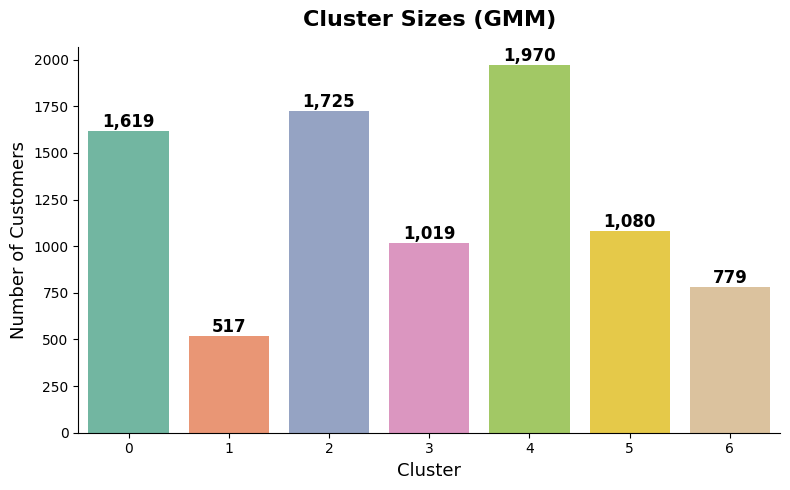

In [ ]:


palette = sns.color_palette("Set2", df['gmm_cluster'].nunique())

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=df,
    x='gmm_cluster',
    palette=palette,
    order=sorted(df['gmm_cluster'].unique()),
    ax=ax
)

ax.set_title('Cluster Sizes (GMM)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Cluster', fontsize=13)
ax.set_ylabel('Number of Customers', fontsize=13)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

#Pick the Cluster Number from the Drop Down List in the Dashboard to see Its characteristics.

In [92]:


# ── Config ────────────────────────────────────────────────────────────────────
FEATURES = [
    'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'
]

PALETTE  = sns.color_palette("Set2", df['gmm_cluster'].nunique())
BG_COLOR = '#F7F9FC'
clusters = sorted(df['gmm_cluster'].unique())

# ── Widgets ───────────────────────────────────────────────────────────────────
dropdown = widgets.Dropdown(
    options=[(f'Cluster {c}', c) for c in clusters],
    description='Cluster:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)

out = widgets.Output()

# ── Plot function ─────────────────────────────────────────────────────────────
def plot_cluster(cluster_id):
    with out:
        clear_output(wait=True)

        sub   = df[df['gmm_cluster'] == cluster_id]
        color = PALETTE[clusters.index(cluster_id)]
        n     = len(sub)
        pct   = n / len(df) * 100

        fig = plt.figure(figsize=(22, 26), facecolor=BG_COLOR)
        fig.suptitle(
            f'Cluster {cluster_id}  ·  {n:,} customers  ({pct:.1f}% of total)',
            fontsize=20, fontweight='bold', y=0.98, color='#2d2d2d'
        )

        gs = gridspec.GridSpec(
            5, 4, figure=fig,
            hspace=0.55, wspace=0.35,
            top=0.94, bottom=0.04, left=0.06, right=0.97
        )

        # ── Row 0-3: distribution plots for each feature ──────────────────────
        for i, feat in enumerate(FEATURES):
            row, col = divmod(i, 4)
            ax = fig.add_subplot(gs[row, col])
            ax.set_facecolor(BG_COLOR)

            sns.histplot(sub[feat], kde=True, color=color, alpha=0.6,
                         line_kws={'lw': 2}, ax=ax)
            sns.kdeplot(df[feat], color='#aaaaaa', lw=1.2,
                        linestyle='--', ax=ax, label='All')

            mean_val   = sub[feat].mean()
            median_val = sub[feat].median()
            ax.axvline(mean_val,   color='#e74c3c', lw=1.5, linestyle='-',  label=f'μ {mean_val:.1f}')
            ax.axvline(median_val, color='#2c3e50', lw=1.5, linestyle=':', label=f'M {median_val:.1f}')

            ax.set_title(feat, fontsize=9, fontweight='bold', color='#2d2d2d')
            ax.set_xlabel('')
            ax.tick_params(labelsize=7)
            ax.legend(fontsize=6, loc='upper right', frameon=False)
            sns.despine(ax=ax)



        # ── Row 4 col 1-2: radar / spider chart ───────────────────────────────
        ax_radar = fig.add_subplot(gs[4, 1:3], polar=True)
        radar_feats = [
            'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
            'PAYMENTS', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY'
        ]
        norm = lambda f: (sub[f].mean() - df[f].min()) / (df[f].max() - df[f].min() + 1e-9)
        values = [norm(f) for f in radar_feats]
        values += values[:1]

        angles = np.linspace(0, 2 * np.pi, len(radar_feats), endpoint=False).tolist()
        angles += angles[:1]

        ax_radar.plot(angles, values, color=color, lw=2)
        ax_radar.fill(angles, values, color=color, alpha=0.25)
        ax_radar.set_xticks(angles[:-1])
        ax_radar.set_xticklabels(
            [f.replace('_', '\n') for f in radar_feats],
            fontsize=7, color='#2d2d2d'
        )
        ax_radar.set_yticklabels([])
        ax_radar.set_title('Feature Profile\n(normalized vs global range)\n',
                            fontsize=9, fontweight='bold', pad=18)



        # ── Row 4 col 3: stats table ──────────────────────────────────────────
        ax_tbl = fig.add_subplot(gs[4, 3])
        ax_tbl.axis('off')
        key_feats = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT',
                     'PAYMENTS', 'CASH_ADVANCE', 'PRC_FULL_PAYMENT']
        tbl_data = [[f, f'{sub[f].mean():.1f}', f'{sub[f].median():.1f}'] for f in key_feats]
        tbl = ax_tbl.table(
            cellText=tbl_data,
            colLabels=['Feature', 'Mean', 'Median'],
            cellLoc='center', loc='center',
            bbox=[0, 0.1, 1, 0.85]
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8)
        for (r, c_), cell in tbl.get_celld().items():
            cell.set_edgecolor('#cccccc')
            if r == 0:
                cell.set_facecolor(color)
                cell.set_text_props(color='white', fontweight='bold')
            else:
                cell.set_facecolor('#ffffff' if r % 2 == 0 else '#f2f2f2')
        ax_tbl.set_title('Key Stats', fontsize=9, fontweight='bold')

        plt.show()

# ── Wire up & display ─────────────────────────────────────────────────────────
def on_change(change):
    if change['name'] == 'value':
        plot_cluster(change['new'])

dropdown.observe(on_change, names='value')

display(widgets.VBox([
    widgets.HTML("<h3 style='font-family:sans-serif;color:#2d2d2d'>🗂️ GMM Cluster Explorer</h3>"),
    dropdown,
    out
]))

plot_cluster(clusters[0])

| Cluster | Label | Risk Level | Core Action |
|---|---|---|---|
| 0 | Pure High Spenders | Low | Retain, upsell premium rewards |
| 1 | Dual Users | Medium | Divert cash advance to personal credit line |
| 2 | Installment Loyalists | Low | Retail instalment partnerships |
| 3 | Occasional Splurgers | Low–Medium | Seasonal campaigns + introduce instalments |
| 4 | Pure Cash Advance | High | Debt relief products + risk monitoring |
| 5 | Maximum Revolvers | High | Balance transfer + relationship management |
| 6 | Cash Advance + Light Buyer | High | Refinancing + purchase behaviour nudges |

#Detailed Explanation in PDF.